In [1]:
!uv add matplotlib pillow

Resolved 92 packages in 1ms
Audited 65 packages in 223ms


In [2]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

In [3]:
DATA_DIR = Path("../data")

### Let's look at the image and label counts.

In [4]:
for split in ["train", "val", "test"]:
    images = list((DATA_DIR / split / "images").glob("*.jpg"))
    labels = list((DATA_DIR / split / "labels").glob("*.txt"))
    print(f"{split}: {len(images)} images, {len(labels)} labels")

train: 3900 images, 3900 labels
val: 1300 images, 1300 labels
test: 1300 images, 1300 labels


dataset is split in a 6:2:2 ratio it's okay but we can change it later. 

Image and label counts match, but we still check that images open and label lines look like valid YOLO rows

In [5]:
bad_images = 0

for split in ["train", "val", "test"]:
    for img_path in (DATA_DIR / split / "images").glob("*.jpg"):
        try:
            Image.open(img_path).verify()
        except Exception as e:
            bad_images += 1

bad_images

0

In [6]:
bad_rows = 0

for split in ["train", "val", "test"]:
    for label_path in (DATA_DIR / split / "labels").glob("*.txt"):
        text = label_path.read_text().strip()
        for line in text.splitlines():
            parts = line.split()
            if len(parts) != 5:
                bad_rows += 1
                continue
            cls_id, xc, yc, w, h = map(float, parts)
            if int(cls_id) not in (0, 1) or not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
                bad_rows += 1

bad_rows


0

No unreadable images and no invalid label rows the dataset looks clean enough to trust for the rest of the analysis.

### We will have a look at a sample label and an image to understand the format

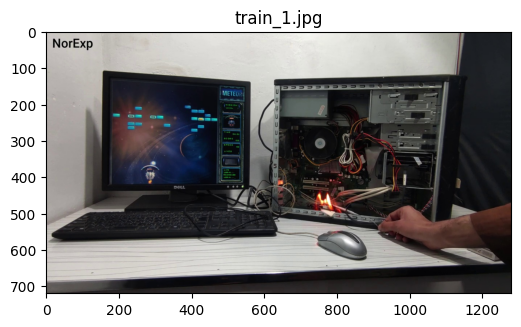

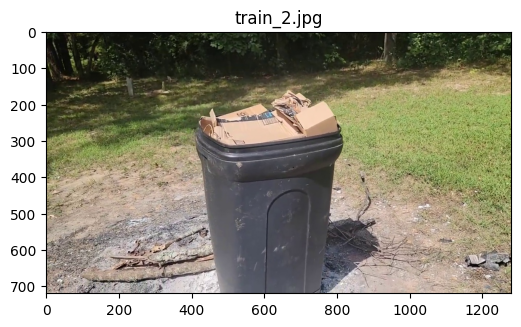

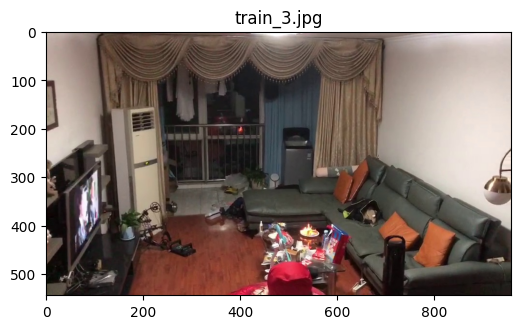

In [7]:
for i in range(1, 4):
    sample_image = DATA_DIR / "train" / "images" / f"train_{i}.jpg"
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(Image.open(sample_image))
    ax.set_title(sample_image.name)
    plt.show()

In [8]:
sample_label = DATA_DIR / "train" / "labels" / "train_1.txt"
print(sample_label.read_text())

0 0.60703125 0.6555555555555556 0.05625 0.08333333333333334



This is a YOLO format. With Class ID, x_center, y_center, width and height respectively. We want to understand which class ID is Smoke, which is Fire. We can see 0 is Fire and 1 is smoke when investigated dataset manually. Some images have both, some have more than 1 Fire etc. It is given line by line

Let's create a helper function to draw bounding boxes onto images -- WE ADDED THESE HELPERS TO HELPER.PY LATER ON

In [9]:
CLASS_IDS = {
    0: {"name": "fire", "color": "red"},
    1: {"name": "smoke", "color": "blue"}
}

In [10]:
def draw_bbox(ax, label_path, img_path):
    img_w, img_h = Image.open(img_path).size
    
    for line in label_path.read_text().strip().splitlines(): # THere can be multiple lines (multiple bounding boxes)
        if not line.strip():
            continue

        cls_id, xc, yc, w, h = map(float, line.split())
        x = (xc - w / 2) * img_w # Calculate top-left x coordinate of the bounding box
        y = (yc - h / 2) * img_h # Calculate top-left y coordinate of the bounding box

        rect = plt.Rectangle(
            (x, y), w * img_w, h * img_h,
            fill=False,
            edgecolor=CLASS_IDS[int(cls_id)]["color"],
            linewidth=2,
        )
        ax.add_patch(rect)

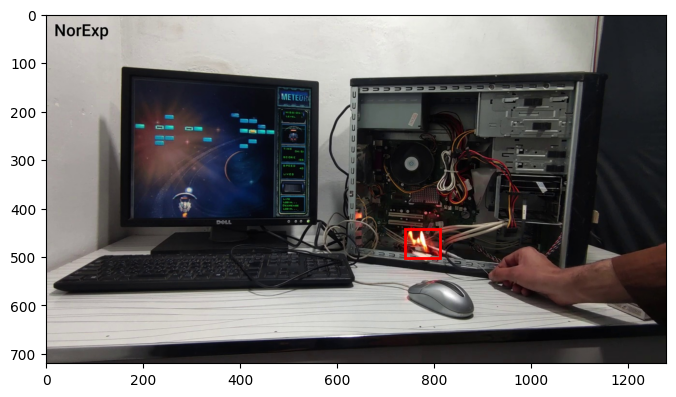

In [11]:
img_path = DATA_DIR / "train" / "images" / "train_1.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_1.txt"

img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
draw_bbox(ax, label_path, img_path)
plt.show()

Lets try another

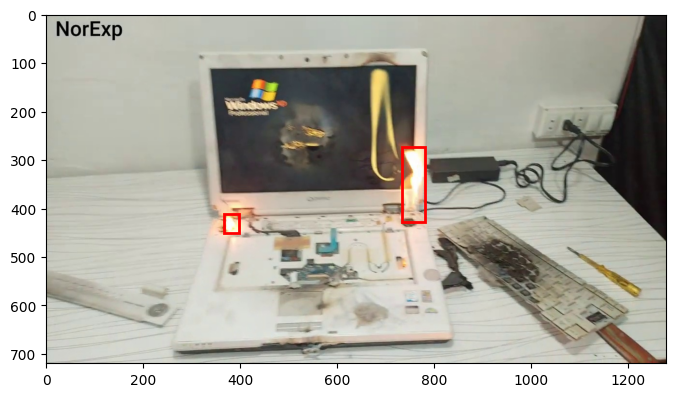

In [12]:
img_path = DATA_DIR / "train" / "images" / "train_4176.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_4176.txt"

img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
draw_bbox(ax, label_path, img_path)
plt.show()

Try one with smokes

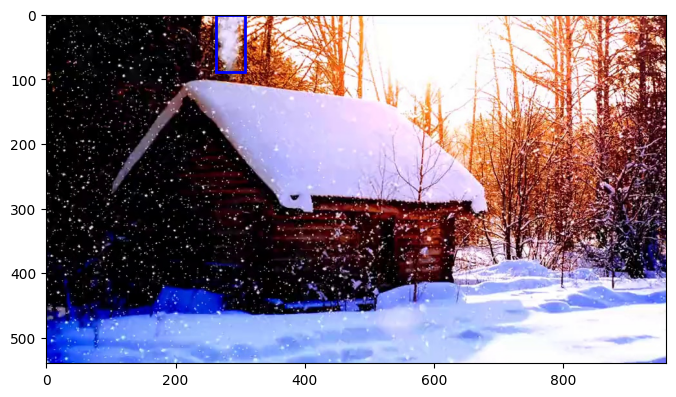

In [13]:
img_path = DATA_DIR / "train" / "images" / "train_4131.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_4131.txt"

img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)
draw_bbox(ax, label_path, img_path)
plt.show()

#### TODO: In the image we see above, there is sunlight, dense snow etc. So image is very hard to detect the smoke. So further on we will need to use some augmentation techniques to make model understand better.

Before training a model, we need to understand the dataset better.

In [14]:
class_counts = {0: 0, 1: 0}
box_areas = []
sizes = []
empty_labels = 0

for split in ["train", "val", "test"]:
    for label_path in (DATA_DIR / split / "labels").glob("*.txt"):
        img = DATA_DIR / split / "images" / f"{label_path.stem}.jpg"
        sizes.append(Image.open(img).size)

        lines = label_path.read_text().strip().splitlines()
        if not lines:
            empty_labels += 1
            continue

        for line in lines:
            cls_id, _, _, w, h = map(float, line.split())
            class_counts[int(cls_id)] += 1
            box_areas.append(w * h)

How many fire vs smoke bounding boxes are there? Is the dataset balanced?

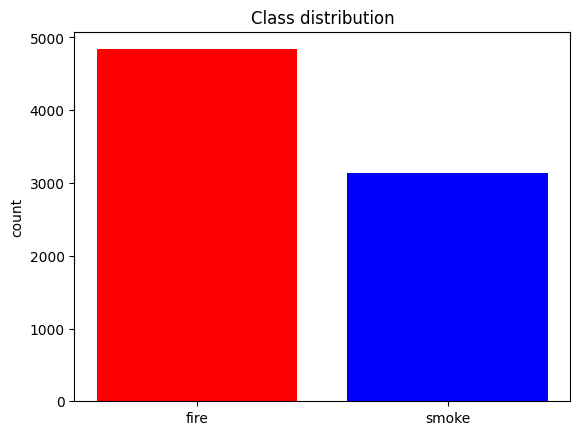

In [15]:
names = [CLASS_IDS[i]["name"] for i in class_counts]
counts = list(class_counts.values())

plt.bar(names, counts, color=["red", "blue"])
plt.title("Class distribution")
plt.ylabel("count")
plt.show()

Fire boxes are more common than smoke → use class weights or oversample smoke during training

The chart above mixes all splits. We now check class balance per split so train/val/test are comparable.

In [35]:
import pandas as pd

rows = []
for split in ["train", "val", "test"]:
    counts = {0: 0, 1: 0}
    for label_path in (DATA_DIR / split / "labels").glob("*.txt"):
        for line in label_path.read_text().strip().splitlines():
            cls_id = int(float(line.split()[0]))
            counts[cls_id] += 1
    rows.append({"split": split, "fire": counts[0], "smoke": counts[1]})

df = pd.DataFrame(rows)
df["smoke_ratio"] = df["smoke"] / (df["fire"] + df["smoke"])
df

,split,fire,smoke,smoke_ratio
0,train,2978,1834,0.381131
1,val,963,617,0.390506
2,test,897,689,0.434426


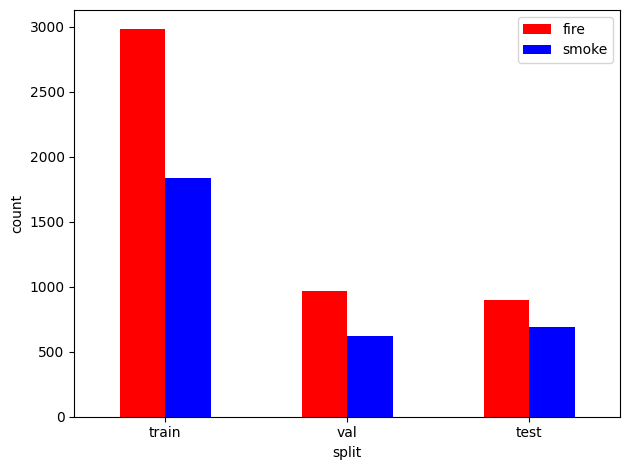

In [36]:
df.plot(x="split", y=["fire", "smoke"], kind="bar", color=["red", "blue"], rot=0)
plt.ylabel("count")
plt.tight_layout()
plt.show()

Fire stays ahead of smoke in every split. Train and val smoke ratios are close test is a bit higher. The split looks usable but smoke is still the minority class everywhere.

Are all images the same size, or do we need to handle different resolutions?

In [16]:
sizes[:5]

[(1280, 720), (1280, 720), (1280, 720), (1280, 720), (1920, 1080)]

In [17]:
len(set(sizes))

45

Images come in many resolutions. YOLO can resize internally but for a custom CNN we will define an explicit letterbox resize below. First the resolution distribution

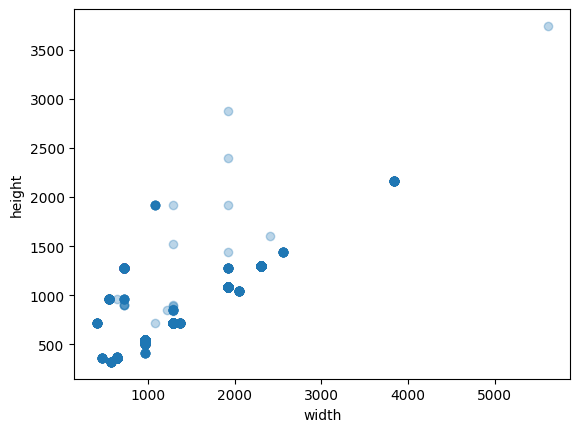

In [18]:
widths = [w for w, h in sizes]
heights = [h for w, h in sizes]

plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("width")
plt.ylabel("height")
plt.show()

Are there many small targets? Small objects are harder to detect.

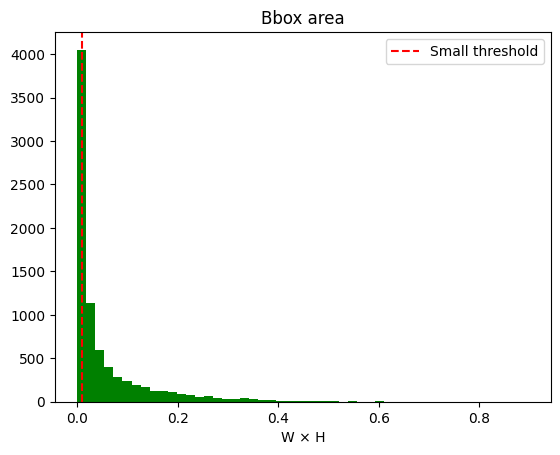

In [19]:
small_threshold = 0.01  # Lets say a bounding box is considered small when it is 1% of the image
plt.hist(box_areas, bins=50, color="green")
plt.axvline(small_threshold, color="red", linestyle="--", label="Small threshold")
plt.title("Bbox area")
plt.xlabel("W × H")
plt.legend()
plt.show()

In [20]:
small = sum(1 for a in box_areas if a < small_threshold)
100 * small / len(box_areas)

39.55878666332414

About 40% of bounding boxes cover less than 1% (based on our choice) of the image area.

Box area alone hides shape. We also look at width and height separately this will matter later for k-means anchor analysis.

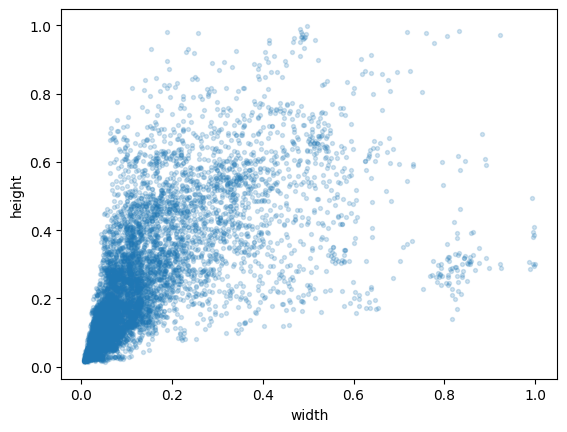

In [38]:
box_ws, box_hs = [], []
for split in ["train", "val", "test"]:
    for label_path in (DATA_DIR / split / "labels").glob("*.txt"):
        for line in label_path.read_text().strip().splitlines():
            _, _, _, w, h = map(float, line.split())
            box_ws.append(w)
            box_hs.append(h)

plt.scatter(box_ws, box_hs, alpha=0.2, s=8)
plt.xlabel("width")
plt.ylabel("height")
plt.show()

Most boxes sit in the small corner. A few boxes span almost the full image. This matches the earlier ~40% small area finding and is exactly why k-means anchors will matter

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

There is no separate "none" class in YOLO. Images with no fire or smoke have an empty label file. We should look at how many of these negative examples we have.

In [21]:
empty_labels

135

Out of all images, 135 have empty label files meaning the dataset is almost entirely containing a bounding box (positive examples).

Earlier we saw that images come in many different resolutions. YOLO can handle resizing internally, but for a shared pipeline and especially for the custom CNN we need to preprocess every image to a common input size

In [22]:
IMG_SIZE = 640

In [23]:
def resize_image(img: Image.Image, target_size: int = IMG_SIZE):
    # resize image while maintaining aspect ratio. Afterwards pad to square.
    orig_width, orig_height = img.size
    scale = min(target_size / orig_width, target_size / orig_height)
    new_width, new_height = round(orig_width * scale), round(orig_height * scale)

    resized = img.resize((new_width, new_height), Image.BICUBIC) #BICUBIC is a good choice for resizing images as we learned in class.

    canvas = Image.new("RGB", (target_size, target_size), (114, 114, 114)) # Standard in ultralytics documents
    pad_x = (target_size - new_width) // 2
    pad_y = (target_size - new_height) // 2
    canvas.paste(resized, (pad_x, pad_y))

    return canvas, scale, pad_x, pad_y

In [24]:
def remap_bbox(xc, yc, w, h, orig_width, orig_height, scale, pad_x, pad_y, target_size=IMG_SIZE):
    abs_xc, abs_yc = xc * orig_width, yc * orig_height
    abs_w, abs_h = w * orig_width, h * orig_height

    new_xc = abs_xc * scale + pad_x
    new_yc = abs_yc * scale + pad_y
    new_w = abs_w * scale
    new_h = abs_h * scale

    new_xc /= target_size
    new_yc /= target_size
    new_w /= target_size
    new_h /= target_size

    return new_xc, new_yc, new_w, new_h

Now we check that these processes keeps boxes aligned.

In [25]:
sample_img_path = DATA_DIR / "train" / "images" / "train_1.jpg"
sample_label_path = DATA_DIR / "train" / "labels" / "train_1.txt"

In [26]:
import sys
sys.path.insert(0, str(Path("..").resolve()))
from helpers.viz import draw_bbox, draw_yolo_boxes

In [27]:
img = Image.open(sample_img_path)
orig_w, orig_h = img.size
canvas, scale, pad_x, pad_y = resize_image(img)

In [28]:
remapped_boxes = []
for line in sample_label_path.read_text().strip().splitlines():
    cls_id, xc, yc, w, h = map(float, line.split())
    remapped_boxes.append(
        (int(cls_id), *remap_bbox(xc, yc, w, h, orig_w, orig_h, scale, pad_x, pad_y))
    )

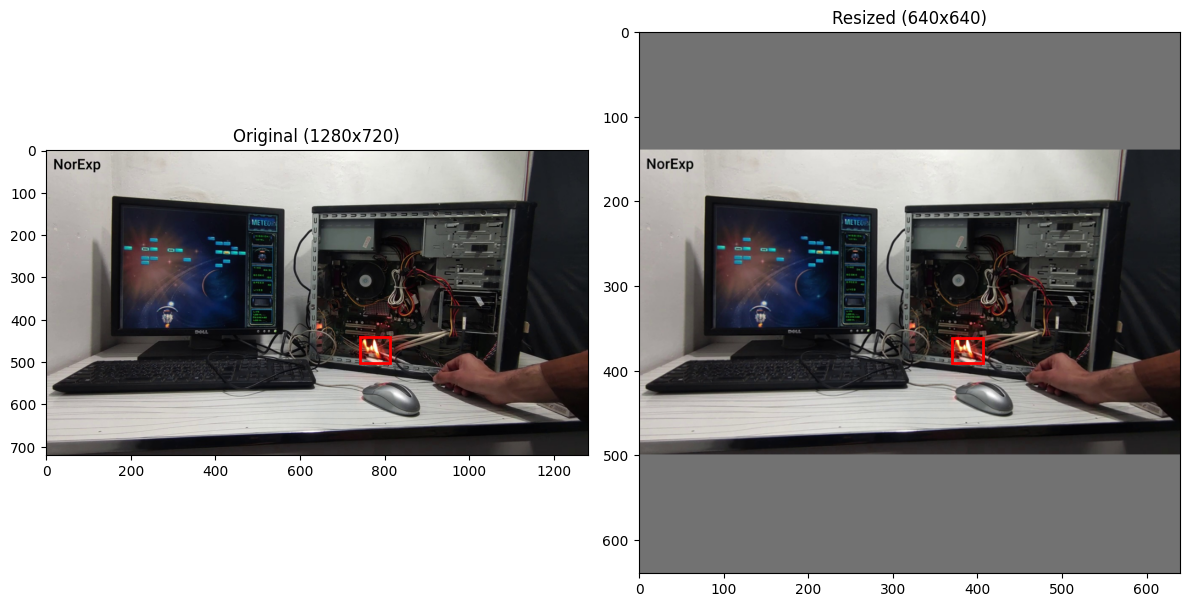

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
draw_bbox(axes[0], sample_label_path, sample_img_path)
axes[0].set_title(f"Original ({orig_w}x{orig_h})")
axes[1].imshow(canvas)
draw_yolo_boxes(axes[1], remapped_boxes, IMG_SIZE, IMG_SIZE)
axes[1].set_title(f"Resized ({IMG_SIZE}x{IMG_SIZE})")
plt.tight_layout()
plt.show()

Letterboxing keeps the original aspect ratio: the image is scaled to fit 640×640, then padded. Stretching to a square would distort fire/smoke shapes.

Letterboxing gives us a shared spatial size. Networks still expect pixel values in a consistent numeric range so we normalize the letterboxed image next

In [30]:
import numpy as np

In [31]:
def normalize_image(img: Image.Image):
    """Convert a PIL image to a float tensor in [0, 1] with shape (C, H, W)."""
    arr = np.asarray(img).astype(np.float32) / 255.0  # H, W, C
    tensor = np.transpose(arr, (2, 0, 1))             # C, H, W
    return tensor

In [32]:
def preprocess(img: Image.Image, target_size: int = IMG_SIZE):
    canvas, scale, pad_x, pad_y = resize_image(img, target_size)
    tensor = normalize_image(canvas)
    return tensor, scale, pad_x, pad_y

We now verify the preprocessing output shape and value range on one training sample.

In [33]:
sample_img_path = DATA_DIR / "train" / "images" / "train_1.jpg"
img = Image.open(sample_img_path)

tensor, scale, pad_x, pad_y = preprocess(img)

print("tensor shape:", tensor.shape)   # expected: (3, 640, 640)
print("dtype:", tensor.dtype)
print("min / max:", float(tensor.min()), float(tensor.max()))
print("scale:", scale, "pad_x:", pad_x, "pad_y:", pad_y)

tensor shape: (3, 640, 640)
dtype: float32
min / max: 0.0 1.0
scale: 0.5 pad_x: 0 pad_y: 140


Preprocessing is ready: every image can be mapped to a shared `(3, 640, 640)` float32 tensor in `[0, 1]` with boxes remapped onto the letterboxed canvas.

EDA + basic preprocessing are done for this notebook